## Load packages and the input file

In [2]:
import sys, os
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from tabulate import tabulate
import h5py
import awkward as ak
import math

## Read file 

In [28]:
read_file = True
if read_file:
    final_df = pd.read_csv('./uubar.csv')
    print(tabulate(final_df.head(), headers='keys', tablefmt='psql'))
    print(tabulate(final_df.tail(), headers='keys', tablefmt='psql'))
print(final_df.shape)

+----+-------------+-------------+-------------+-------------+-------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-----------------+-----------------+-----------------+-----------------+-----------------+-------------+-------------+-------------+-------------+-------------+---------+-----------+-----------+-----------+------------+----------------+------------------+------------------+------------------+----------------+---------+-----------+-----------+-----------+------------+----------------+------------------+------------------+------------------+----------------+---------+------------+------------+------------+------------+---------+------------+------------+------------+------------+---------+-----------+-----------+-----------+------------+---------+-----------+-----------+-----------+------------+----------------+--------------+--------------------+------------+
|    

## Feature preprocessing

In [29]:
NDIM = len(final_df.keys()) - 1
#dataset = final_df.values

# Count NaNs in each column
df_nonan = final_df.copy()
df_nonan = df_nonan.dropna()
#print(df_nonan.isna().sum())
dataset = df_nonan.values
X = dataset[:,0:NDIM]
Y = dataset[:,NDIM]

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

# preprocessing: standard scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Check for NaNs/Infs in the dataset
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

In [31]:
print(type(X))
print(X.shape)
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(35233, 68)
<class 'numpy.ndarray'>
(28186, 68)


## Particle transformer

In [6]:
# Plain (no-interaction) Particle Transformer for tabular / constituent-like inputs
# - 1. Particle embedding (MLP: 128 -> 512 -> 128 with LayerNorm + GELU)
# - 2. Particle attention blocks (standard MHSA, no pair/interaction bias)
# - 3. Class attention blocks (CaiT-style: cls queries particles)
#
# Works with:
#   x_particles: (B, P, F)  where:
#       B = batch size
#       P = number of “particles/tokens” per event (can be 69 if you treat each feature as a token)
#       or (B, 69, 1) each feature is treated as a “particle”
#       F = features per particle/token
#   mask (optional): (B, P) with 1 for real tokens and 0 for padded tokens

import torch
import torch.nn as nn
from typing import Optional, Sequence


class ParticleEmbed(nn.Module):
    """
    Per-particle MLP embedding like ParT:
      Linear -> LN -> GELU  (x3) with widths [128, 512, embed_dim]
    """
    def __init__(self, input_dim: int, embed_dims: Sequence[int] = (128, 512, 128)):
        super().__init__()
        dims = [input_dim] + list(embed_dims)
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                nn.Linear(dims[i], dims[i + 1]),
                nn.LayerNorm(dims[i + 1]),
                nn.GELU(),
            ]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, P, F)  like (B, 69, 1) each feature is treated as a “particle” -- token dim = 1
        return self.net(x)  # (B, P, C)


class ParticleBlock(nn.Module):
    """
    Transformer block (pre-LN) for particle self-attention.
    No interaction embedding / no pair bias.
    PyTorch module (a reusable layer). It will contain:
    self-attention
    feed-forward network (FFN)
    residual connections
    normalization
    dropout
    """
    def __init__(
        self,
        embed_dim: int = 128,                # vector size for each token (C)
        num_heads: int = 8,                  # number of attention heads               
        ffn_ratio: int = 4,                  # hidden size in FFN = embed_dim * ffn_ratio
        dropout: float = 0.1,
        attn_dropout: float = 0.1,
        activation_dropout: float = 0.1,
    ):
        super().__init__()

        # Multi-head self-attention
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,  # (B, P, C)
        )
        self.drop1 = nn.Dropout(dropout)

        # Feed-forward network (MLP)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(activation_dropout),
            nn.Linear(hidden, embed_dim),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # x: (B, P, C)
        # key_padding_mask: (B, P) with True for PAD positions (PyTorch convention)
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)    # h for query, key, value
        x = x + self.drop1(h)

        h = self.norm2(x)
        h = self.ffn(h)
        x = x + self.drop2(h)
        return x


class ClassAttentionBlock(nn.Module):
    """
    CaiT-style class attention:
      - cls token attends to [cls + particles]
      - particles are NOT updated in cls blocks (only cls updates)
    """
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        ffn_ratio: int = 4,
        dropout: float = 0.0,        # ParT often uses 0 in cls blocks
        attn_dropout: float = 0.0,
        activation_dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,  # (B, T, C)
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(activation_dropout),
            nn.Linear(hidden, embed_dim),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(
        self,
        x_particles: torch.Tensor,          # (B, P, C)
        x_cls: torch.Tensor,                # (B, 1, C)
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Build tokens [cls, particles]
        u = torch.cat([x_cls, x_particles], dim=1)  # (B, 1+P, C)

        # Expand padding mask to include cls (cls is never padded)
        if key_padding_mask is not None:
            cls_pad = torch.zeros((key_padding_mask.size(0), 1), device=key_padding_mask.device, dtype=torch.bool)
            pad_u = torch.cat([cls_pad, key_padding_mask], dim=1)  # (B, 1+P)
        else:
            pad_u = None

        # Attention: query = cls only, key/value = [cls + particles]
        residual = x_cls
        q = self.norm1(x_cls)  # (B, 1, C)
        kv = self.norm1(u)     # (B, 1+P, C)
        h, _ = self.attn(q, kv, kv, key_padding_mask=pad_u, need_weights=False)
        x_cls = residual + self.drop1(h)

        # FFN on cls only
        residual = x_cls
        h = self.norm2(x_cls)
        h = self.ffn(h)
        x_cls = residual + self.drop2(h)
        return x_cls  # (B, 1, C)


class PlainParticleTransformer(nn.Module):
    """
    Full model:
      embed -> N particle blocks -> M class-attention blocks -> norm -> head
    """
    def __init__(
        self,
        input_dim: int,                     # features per token/particle
        num_classes: int = 2,
        num_tokens: Optional[int] = None,   # not required; kept for clarity
        embed_dims=(128, 512, 128),         # embedding dimensions for ParticleEmbed MLP
        embed_dim: int = 128,               # must match last of embed_dims
        num_heads: int = 8,
        num_layers: int = 8,
        num_cls_layers: int = 2,
        ffn_ratio: int = 4,
        dropout: float = 0.1,
        attn_dropout: float = 0.1,
        activation_dropout: float = 0.1,
        cls_dropout: float = 0.0,           # typical ParT default for cls blocks
        fc_hidden: Optional[int] = None,    # e.g., 256 if you want an extra FC layer
    ):
        super().__init__()

        assert embed_dim == embed_dims[-1], "embed_dim must equal embed_dims[-1]"

        self.embed = ParticleEmbed(input_dim=input_dim, embed_dims=embed_dims)

        self.blocks = nn.ModuleList([
            ParticleBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ffn_ratio=ffn_ratio,
                dropout=dropout,
                attn_dropout=attn_dropout,
                activation_dropout=activation_dropout,
            )
            for _ in range(num_layers)
        ])

        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ffn_ratio=ffn_ratio,
                dropout=cls_dropout,
                attn_dropout=cls_dropout,
                activation_dropout=cls_dropout,
            )
            for _ in range(num_cls_layers)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        if fc_hidden is None:
            self.head = nn.Linear(embed_dim, num_classes)
        else:
            self.head = nn.Sequential(
                nn.Linear(embed_dim, fc_hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(fc_hidden, num_classes),
            )

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: (B, P, F)
        mask (optional): (B, P) with 1 for real tokens and 0 for padded tokens
        """
        if mask is None:
            key_padding_mask = None
        else:
            # PyTorch MHA expects True where positions are padded
            key_padding_mask = ~mask.bool()  # (B, P)

        # Embed particles
        x = self.embed(x)  # (B, P, C)

        # Zero-out padded tokens (optional but often helps)
        if mask is not None:
            x = x.masked_fill((~mask.bool()).unsqueeze(-1), 0.0)

        # Particle (self) attention blocks
        for blk in self.blocks:
            x = blk(x, key_padding_mask=key_padding_mask)

        # Class attention blocks (only update cls token)
        B = x.size(0)
        cls = self.cls_token.expand(B, 1, -1)  # (B, 1, C)
        for cblk in self.cls_blocks:
            cls = cblk(x_particles=x, x_cls=cls, key_padding_mask=key_padding_mask)

        cls = self.norm(cls).squeeze(1)  # (B, C)
        logits = self.head(cls)          # (B, num_classes)
        return logits


# -------------------------------------------------------------------------
# How to use it for YOUR case (30k events, 69 features):
# Option A (recommended for your current CSV tabular setup):
#   Treat each scalar feature as a "token" => P=69, F=1
#
#   X: (B, 69)  ->  x = X.unsqueeze(-1) => (B, 69, 1)
#   model = PlainParticleTransformer(input_dim=1, num_classes=2, num_layers=8, num_cls_layers=2)
#
# Option B (if you actually have constituent structure):
#   x already is (B, P, F) and mask is (B, P)
# -------------------------------------------------------------------------

if __name__ == "__main__":
    # Example for tabular X with 69 features => tokens=69, per-token dim=1
    B = 16
    X = torch.randn(B, 69)                 # your standardized features
    x_tokens = X.unsqueeze(-1)             # (B, 69, 1)

    model = PlainParticleTransformer(
        input_dim=1,
        num_classes=2,
        num_layers=8,
        num_cls_layers=2,
        num_heads=8,
        embed_dims=(128, 512, 128),
        dropout=0.1,
    )

    logits = model(x_tokens)               # (B, 2)
    print(logits.shape)


torch.Size([16, 2])


## Transformer on GPU

In [32]:
# GPU-ready training template for the PlainParticleTransformer (no interaction embedding)
# - Moves model + batches to CUDA (if available)
# - Verbose logs: batch loss (optional), epoch loss, accuracy, AUC
# - Uses AMP (mixed precision) for speed on modern GPUs
#
# Assumes already have X (N, 69) and y (N,) in numpy arrays or torch tensors.

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Optional, Sequence

# ----------------------------
# 1) Transformer model includes ParticleEmbed, ParticleBlock, ClassAttentionBlock, and PlainParticleTransformer  
# ----------------------------

# Plain (no-interaction) Particle Transformer for tabular / constituent-like inputs
# - 1. Particle embedding (MLP: 128 -> 512 -> 128 with LayerNorm + GELU)
# - 2. Particle attention blocks (standard MHSA, no pair/interaction bias)
# - 3. Class attention blocks (CaiT-style: cls queries particles)
#
# Works with:
#   x_particles: (B, P, F)  where:
#       B = batch size
#       P = number of “particles/tokens” per event (can be 69 if you treat each feature as a token)
#       or (B, 69, 1) each feature is treated as a “particle”
#       F = features per particle/token
#   mask (optional): (B, P) with 1 for real tokens and 0 for padded tokens


class ParticleEmbed(nn.Module):
    """
    Per-particle MLP embedding like ParT:
      Linear -> LN -> GELU  (x3) with widths [128, 512, embed_dim]
    """
    def __init__(self, input_dim: int, embed_dims: Sequence[int] = (128, 512, 128)):
        super().__init__()
        dims = [input_dim] + list(embed_dims)
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                nn.Linear(dims[i], dims[i + 1]),
                nn.LayerNorm(dims[i + 1]),
                nn.GELU(),
            ]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, P, F)  like (B, 69, 1) each feature is treated as a “particle” -- token dim = 1
        return self.net(x)  # (B, P, C)


class ParticleBlock(nn.Module):
    """
    Transformer block (pre-LN) for particle self-attention.
    No interaction embedding / no pair bias.
    PyTorch module (a reusable layer). It will contain:
    self-attention
    feed-forward network (FFN)
    residual connections
    normalization
    dropout
    """
    def __init__(
        self,
        embed_dim: int = 128,                # vector size for each token (C)
        num_heads: int = 8,                  # number of attention heads               
        ffn_ratio: int = 4,                  # hidden size in FFN = embed_dim * ffn_ratio
        dropout: float = 0.1,
        attn_dropout: float = 0.1,
        activation_dropout: float = 0.1,
    ):
        super().__init__()

        # Multi-head self-attention
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,  # (B, P, C)
        )
        self.drop1 = nn.Dropout(dropout)

        # Feed-forward network (MLP)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(activation_dropout),
            nn.Linear(hidden, embed_dim),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # x: (B, P, C)
        # key_padding_mask: (B, P) with True for PAD positions (PyTorch convention)
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)    # h for query, key, value
        x = x + self.drop1(h)

        h = self.norm2(x)
        h = self.ffn(h)
        x = x + self.drop2(h)
        return x


class ClassAttentionBlock(nn.Module):
    """
    CaiT-style class attention:
      - cls token attends to [cls + particles]
      - particles are NOT updated in cls blocks (only cls updates)
    """
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        ffn_ratio: int = 4,
        dropout: float = 0.0,        # ParT often uses 0 in cls blocks
        attn_dropout: float = 0.0,
        activation_dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,  # (B, T, C)
        )
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(activation_dropout),
            nn.Linear(hidden, embed_dim),
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(
        self,
        x_particles: torch.Tensor,          # (B, P, C)
        x_cls: torch.Tensor,                # (B, 1, C)
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Build tokens [cls, particles]
        u = torch.cat([x_cls, x_particles], dim=1)  # (B, 1+P, C)

        # Expand padding mask to include cls (cls is never padded)
        if key_padding_mask is not None:
            cls_pad = torch.zeros((key_padding_mask.size(0), 1), device=key_padding_mask.device, dtype=torch.bool)
            pad_u = torch.cat([cls_pad, key_padding_mask], dim=1)  # (B, 1+P)
        else:
            pad_u = None

        # Attention: query = cls only, key/value = [cls + particles]
        residual = x_cls
        q = self.norm1(x_cls)  # (B, 1, C)
        kv = self.norm1(u)     # (B, 1+P, C)
        h, _ = self.attn(q, kv, kv, key_padding_mask=pad_u, need_weights=False)
        x_cls = residual + self.drop1(h)

        # FFN on cls only
        residual = x_cls
        h = self.norm2(x_cls)
        h = self.ffn(h)
        x_cls = residual + self.drop2(h)
        return x_cls  # (B, 1, C)


class PlainParticleTransformer(nn.Module):
    """
    Full model:
      embed -> N particle blocks -> M class-attention blocks -> norm -> head
    """
    def __init__(
        self,
        input_dim: int,                     # features per token/particle
        num_classes: int = 2,
        num_tokens: Optional[int] = None,   # not required; kept for clarity
        embed_dims=(128, 512, 128),         # embedding dimensions for ParticleEmbed MLP
        embed_dim: int = 128,               # must match last of embed_dims
        num_heads: int = 8,
        num_layers: int = 8,
        num_cls_layers: int = 2,
        ffn_ratio: int = 4,
        dropout: float = 0.1,
        attn_dropout: float = 0.1,
        activation_dropout: float = 0.1,
        cls_dropout: float = 0.0,           # typical ParT default for cls blocks
        fc_hidden: Optional[int] = None,    # e.g., 256 if you want an extra FC layer
    ):
        super().__init__()

        assert embed_dim == embed_dims[-1], "embed_dim must equal embed_dims[-1]"

        self.embed = ParticleEmbed(input_dim=input_dim, embed_dims=embed_dims)

        self.blocks = nn.ModuleList([
            ParticleBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ffn_ratio=ffn_ratio,
                dropout=dropout,
                attn_dropout=attn_dropout,
                activation_dropout=activation_dropout,
            )
            for _ in range(num_layers)
        ])

        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ffn_ratio=ffn_ratio,
                dropout=cls_dropout,
                attn_dropout=cls_dropout,
                activation_dropout=cls_dropout,
            )
            for _ in range(num_cls_layers)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        if fc_hidden is None:
            self.head = nn.Linear(embed_dim, num_classes)
        else:
            self.head = nn.Sequential(
                nn.Linear(embed_dim, fc_hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(fc_hidden, num_classes),
            )

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: (B, P, F)
        mask (optional): (B, P) with 1 for real tokens and 0 for padded tokens
        """
        if mask is None:
            key_padding_mask = None
        else:
            # PyTorch MHA expects True where positions are padded
            key_padding_mask = ~mask.bool()  # (B, P)

        # Embed particles
        x = self.embed(x)  # (B, P, C)

        # Zero-out padded tokens (optional but often helps)
        if mask is not None:
            x = x.masked_fill((~mask.bool()).unsqueeze(-1), 0.0)

        # Particle (self) attention blocks
        for blk in self.blocks:
            x = blk(x, key_padding_mask=key_padding_mask)

        # Class attention blocks (only update cls token)
        B = x.size(0)
        cls = self.cls_token.expand(B, 1, -1)  # (B, 1, C)
        for cblk in self.cls_blocks:
            cls = cblk(x_particles=x, x_cls=cls, key_padding_mask=key_padding_mask)

        cls = self.norm(cls).squeeze(1)  # (B, C)
        logits = self.head(cls)          # (B, num_classes)
        return logits

In [33]:
# ----------------------------
# 2) Dataset + split (no sklearn)
# ----------------------------

class TabJets(Dataset):
    """
    If your data is (N, 69) flat features:
      we treat each scalar feature as a token -> (69, 1)
    """
    def __init__(self, X, y):
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        if isinstance(y, np.ndarray):
            y = torch.from_numpy(y).long()
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        x = self.X[i].unsqueeze(-1)  # (69,) -> (69,1)
        y = self.y[i]
        return x, y

def simple_split_indices(n, val_frac=0.2, seed=123):
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_val = int(n * val_frac)
    val_idx = perm[:n_val]
    trn_idx = perm[n_val:]
    return trn_idx, val_idx

def stratified_split_indices(y, val_frac=0.2, seed=123):
    """
    y: torch tensor (N,) or numpy array (N,) with class labels 0/1
    returns: train_idx, val_idx as torch.LongTensor
    """
    if isinstance(y, np.ndarray):
        y = torch.from_numpy(y)
    y = y.long()

    g = torch.Generator().manual_seed(seed)

    idx0 = torch.where(y == 0)[0]
    idx1 = torch.where(y == 1)[0]

    # shuffle within each class
    idx0 = idx0[torch.randperm(idx0.numel(), generator=g)]
    idx1 = idx1[torch.randperm(idx1.numel(), generator=g)]

    n0_val = max(1, int(idx0.numel() * val_frac))
    n1_val = max(1, int(idx1.numel() * val_frac))

    val_idx = torch.cat([idx0[:n0_val], idx1[:n1_val]])
    trn_idx = torch.cat([idx0[n0_val:], idx1[n1_val:]])

    # shuffle final indices
    val_idx = val_idx[torch.randperm(val_idx.numel(), generator=g)]
    trn_idx = trn_idx[torch.randperm(trn_idx.numel(), generator=g)]

    return trn_idx, val_idx


In [34]:
# ----------------------------
# 3) Metrics helpers
# ----------------------------

@torch.no_grad()
def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

@torch.no_grad()
def auc_binary_from_probs(probs_pos, y_true):
    """
    Simple AUC without sklearn (O(N log N)).
    probs_pos: (N,) probabilities of class 1
    y_true: (N,) 0/1
    """
    # Sort by score descending
    scores, idx = torch.sort(probs_pos, descending=True)
    y = y_true[idx].float()
    # Compute ranks-based AUC
    # AUC = (sum ranks of positives - n_pos*(n_pos+1)/2) / (n_pos*n_neg)
    # Here rank 1 is lowest; easier if we sort ascending:
    scores_a, idx_a = torch.sort(probs_pos, descending=False)
    y_a = y_true[idx_a].float()
    ranks = torch.arange(1, y_a.numel() + 1, device=y_a.device).float()
    n_pos = y_a.sum()
    n_neg = y_a.numel() - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    rank_sum_pos = (ranks * y_a).sum()
    auc = (rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return auc.item()

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_n = 0
    all_probs = []
    all_y = []
    ce = nn.CrossEntropyLoss(reduction="sum")
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = ce(logits, y)
        total_loss += loss.item()
        total_n += y.numel()
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.detach())
        all_y.append(y.detach())
    all_probs = torch.cat(all_probs)
    all_y = torch.cat(all_y)
    avg_loss = total_loss / max(total_n, 1)
    #acc = accuracy_from_logits(torch.stack([1-all_probs, all_probs], dim=1), all_y)
    # compute acc from logits for correctness
    # easiest: store logits too, or recompute via threshold:
    pred = (all_probs >= 0.5).long()
    acc = (pred == all_y).float().mean().item()
    auc = auc_binary_from_probs(all_probs, all_y)
    return avg_loss, acc, auc

In [35]:
X.shape

(35233, 68)

In [40]:
# ----------------------------
# 4) Training loop with CUDA + verbose
# ----------------------------

def train_model(
    X, Y,
    epochs=1,
    batch_size=512,
    lr=2e-4,
    weight_decay=1e-4,
    val_frac=0.2,
    seed=123,
    log_every=50,          # print every N batches
    use_amp=True,
    num_workers=2,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device} | CUDA available: {torch.cuda.is_available()}")

    ds = TabJets(X, Y)
    #trn_idx, val_idx = simple_split_indices(len(ds), val_frac=val_frac, seed=seed)

    # stratified split to guarantee both classes exist in val
    trn_idx, val_idx = stratified_split_indices(ds.y, val_frac=val_frac, seed=seed)

    # sanity prints
    y_trn = ds.y[trn_idx]
    y_val = ds.y[val_idx]
    print("Train class counts:", torch.bincount(y_trn))
    print("Val   class counts:", torch.bincount(y_val))

    trn_ds = torch.utils.data.Subset(ds, trn_idx.tolist())
    val_ds = torch.utils.data.Subset(ds, val_idx.tolist())

    loader_trn = DataLoader(
        trn_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda"),
        persistent_workers=(num_workers > 0),
    )
    loader_val = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda"),
        persistent_workers=(num_workers > 0),
    )

    model = PlainParticleTransformer(
        input_dim=1,        # because tokens are scalars (68,1)
        num_classes=2,
        num_layers=8,
        num_cls_layers=2,
        num_heads=8,
        dropout=0.1,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce = nn.CrossEntropyLoss()

    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    best_val_auc = -1.0
    history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        running = 0.0
        n_seen = 0

        for step, (x, yb) in enumerate(loader_trn, start=1):
            x = x.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
                logits = model(x)
                loss = ce(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            running += loss.item() * yb.size(0)
            n_seen += yb.size(0)

            if log_every and (step % log_every == 0):
                # quick batch diagnostics
                with torch.no_grad():
                    acc_b = accuracy_from_logits(logits, yb)
                avg = running / max(n_seen, 1)
                print(f"Epoch {epoch:03d} | step {step:04d}/{len(loader_trn)} | "
                      f"loss {avg:.4f} | batch_acc {acc_b:.3f}")

        trn_loss = running / max(n_seen, 1)
        # Compute train accuracy at end of epoch
        model.eval()
        with torch.no_grad():
            all_probs_tr = []
            all_y_tr = []
            for x_tr, y_tr in loader_trn:
                x_tr = x_tr.to(device)
                y_tr = y_tr.to(device)
                logits_tr = model(x_tr)
                probs_tr = torch.softmax(logits_tr, dim=1)[:, 1]
                all_probs_tr.append(probs_tr)
                all_y_tr.append(y_tr)

            all_probs_tr = torch.cat(all_probs_tr)
            all_y_tr = torch.cat(all_y_tr)
            train_acc = ((all_probs_tr >= 0.5).long() == all_y_tr).float().mean().item()

        val_loss, val_acc, val_auc = evaluate(model, loader_val, device)
        dt = time.time() - t0

        improved = val_auc > best_val_auc
        if improved:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # Store metrics
        history["train_loss"].append(trn_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        print(f"[Epoch {epoch:03d}] time {dt:.1f}s | "
              f"train_loss {trn_loss:.4f} | val_loss {val_loss:.4f} | "
              f"val_acc {val_acc:.3f} | val_auc {val_auc:.4f} "
              f"{'<= BEST' if improved else ''}")

    # restore best
    model.load_state_dict(best_state)
    model.to(device)
    print(f"Best val AUC: {best_val_auc:.4f}")
    return model, device, history

In [45]:
# ----------------------------
# 5) Example call
# ----------------------------
# X: (N, 68), Y: (N,) with labels 0/1
def main():
    model, device, history = train_model(
        X, Y,
        epochs=40,
        batch_size=512,
        log_every=25,
        use_amp=True,
        num_workers=0,   # now you can use >0 safely
    )
    return model, device, history

if __name__ == "__main__":
    import torch.multiprocessing as mp
    mp.freeze_support()   # important on Windows
    model, device, history = main()


Device: cuda | CUDA available: True
Train class counts: tensor([14832, 13355])
Val   class counts: tensor([3708, 3338])


C:\Users\meisa\AppData\Local\Temp\ipykernel_48840\474307237.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))
C:\Users\meisa\AppData\Local\Temp\ipykernel_48840\474307237.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


Epoch 001 | step 0025/56 | loss 0.8606 | batch_acc 0.473
Epoch 001 | step 0050/56 | loss 0.7745 | batch_acc 0.578
[Epoch 001] time 3.1s | train_loss 0.7661 | val_loss 0.6817 | val_acc 0.564 | val_auc 0.5847 <= BEST
Epoch 002 | step 0025/56 | loss 0.6803 | batch_acc 0.590
Epoch 002 | step 0050/56 | loss 0.6791 | batch_acc 0.562
[Epoch 002] time 2.8s | train_loss 0.6789 | val_loss 0.6804 | val_acc 0.560 | val_auc 0.5869 <= BEST
Epoch 003 | step 0025/56 | loss 0.6786 | batch_acc 0.570
Epoch 003 | step 0050/56 | loss 0.6783 | batch_acc 0.607
[Epoch 003] time 2.9s | train_loss 0.6781 | val_loss 0.6800 | val_acc 0.560 | val_auc 0.5904 <= BEST
Epoch 004 | step 0025/56 | loss 0.6761 | batch_acc 0.580
Epoch 004 | step 0050/56 | loss 0.6758 | batch_acc 0.598
[Epoch 004] time 3.0s | train_loss 0.6751 | val_loss 0.6755 | val_acc 0.571 | val_auc 0.6030 <= BEST
Epoch 005 | step 0025/56 | loss 0.6691 | batch_acc 0.607
Epoch 005 | step 0050/56 | loss 0.6713 | batch_acc 0.578
[Epoch 005] time 2.9s | tr

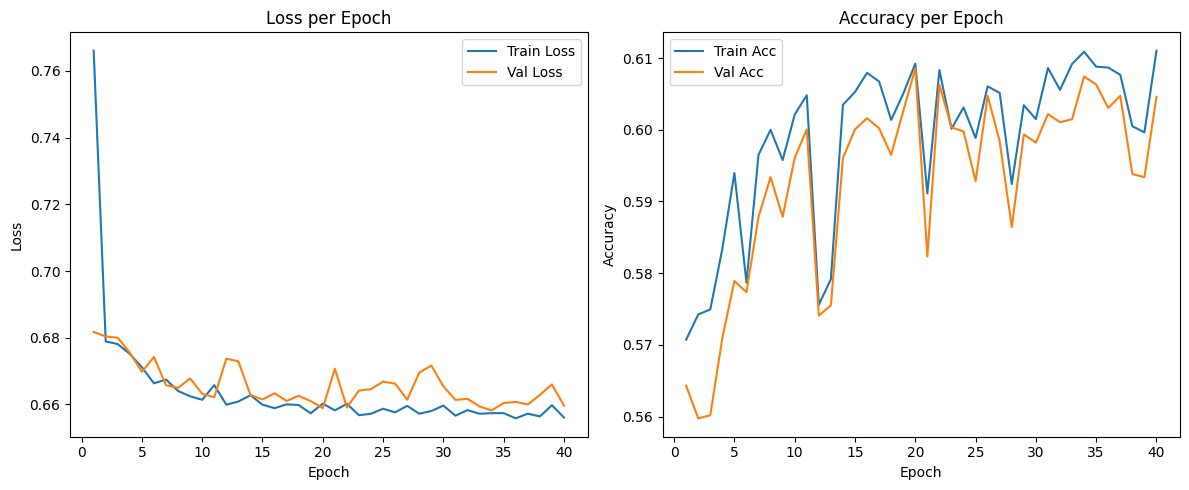

In [46]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,5))

# ----- Loss -----
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()

# ----- Accuracy -----
plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()

plt.tight_layout()
plt.show()

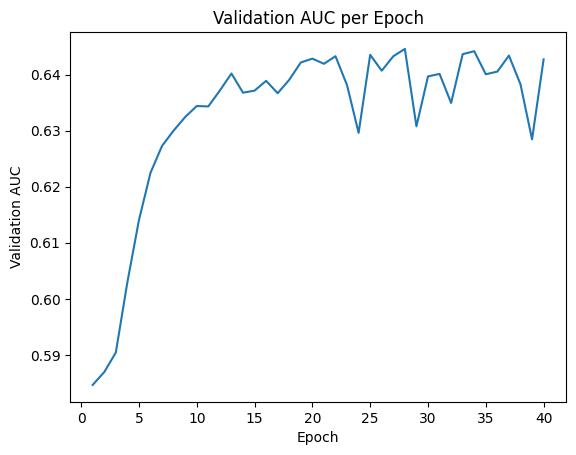

In [47]:
plt.figure()
plt.plot(epochs, history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC per Epoch")
plt.show()

In [ ]:
# Input embedding

import torch
import torch.nn as nn

class ParticleEmbedding(nn.Module):
    def __init__(self, input_dim=17, embed_dim=128):
        super(ParticleEmbedding, self).__init__()
        
        # The paper specifies a 3-layer MLP with 128, 512, 128 nodes 
        # and LayerNorm (LN) for normalization.
        self.embedding_mlp = nn.Sequential(
            # Layer 1: Project 17 features to 128
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            
            # Layer 2: Upscale to 512
            nn.Linear(128, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            
            # Layer 3: Final projection to embedding dimension (128)
            nn.Linear(512, embed_dim),
            nn.LayerNorm(embed_dim)
        )

    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, num_particles, 17)
        Returns:
            Embedded tensor of shape (batch_size, num_particles, 128)
        """
        # x is treated as a "particle cloud"
        return self.embedding_mlp(x)

In [ ]:
import torch
import torch.nn as nn

class PlainParticleAttentionBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8, mlp_ratio=4, dropout=0.1):
        super(PlainParticleAttentionBlock, self).__init__()
        
        # 1. Multi-Head Attention (Plain version without interaction bias)
        # In the paper, each head has a dimension of 16 (8 heads * 16 = 128)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim, 
            num_heads=num_heads, 
            dropout=dropout, 
            batch_first=True
        )
        
        # 2. The MLP (Feed-Forward Network)
        # The paper uses a 2-layer MLP with an expansion factor (128 -> 512 -> 128)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(dropout)
        )
        
        # 3. Layer Normalization (NormFormer style)
        # We need four norms: before and after the Attention, and before and after the MLP
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.norm4 = nn.LayerNorm(embed_dim)
        
        # 4. Scaling Factors (Gamma)
        # NormFormer uses learnable scaling factors initialized at a small value
        self.gamma1 = nn.Parameter(torch.ones(embed_dim) * 1e-4)
        self.gamma2 = nn.Parameter(torch.ones(embed_dim) * 1e-4)

    def forward(self, x):
        """
        x: Input tensor of shape (batch_size, num_particles, embed_dim)
        """
        
        # --- Stage 1: Multi-Head Attention ---
        # Pre-Norm
        x_norm = self.norm1(x)
        
        # Attention (Self-attention: Q, K, and V are all the same)
        # Note: In a plain transformer, we don't add the Interaction Matrix 'U' here.
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        
        # Post-Norm + Scale + Residual Connection
        x = x + self.gamma1 * self.norm2(attn_out)
        
        # --- Stage 2: Feed-Forward Network (MLP) ---
        # Pre-Norm
        x_norm = self.norm3(x)
        
        # MLP
        mlp_out = self.mlp(x_norm)
        
        # Post-Norm + Scale + Residual Connection
        x = x + self.gamma2 * self.norm4(mlp_out)
        
        return x

In [ ]:
import torch
import torch.nn as nn

class ClassAttentionBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=8, mlp_ratio=4, dropout=0.1):
        super(ClassAttentionBlock, self).__init__()
        
        # 1. Multi-Head Attention (MHA)
        # Note: In class attention, we use standard MHA (no physics interaction bias U)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim, 
            num_heads=num_heads, 
            dropout=dropout, 
            batch_first=True
        )

        # 2. Feed-Forward Network (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(dropout)
        )
        
        # 3. NormFormer-style Layer Normalization
        # We need norms for the Query (class token), the Keys/Values (particles), 
        # and for the MLP stages.
        self.norm_q = nn.LayerNorm(embed_dim)
        self.norm_k = nn.LayerNorm(embed_dim)
        self.norm_v = nn.LayerNorm(embed_dim)
        self.norm_post_attn = nn.LayerNorm(embed_dim)
        self.norm_pre_mlp = nn.LayerNorm(embed_dim)
        self.norm_post_mlp = nn.LayerNorm(embed_dim)
        
        # 4. Learnable Scaling Factors (Gamma)
        # These are initialized to a small value (1e-4) to stabilize early training
        self.gamma1 = nn.Parameter(torch.ones(embed_dim) * 1e-4)
        self.gamma2 = nn.Parameter(torch.ones(embed_dim) * 1e-4)

    def forward(self, x_class, x_particles):
        """
        Args:
            x_class: The class token [Batch, 1, 128]
            x_particles: Particle embeddings from previous blocks [Batch, N, 128]
        """
        
        # --- Stage 1: Attention (Class token queries the particles) ---
        # Pre-Norm for Query, Key, and Value
        # Query comes ONLY from x_class
        q = self.norm_q(x_class)
        # Keys and Values come from the particles
        k = self.norm_k(x_particles)
        v = self.norm_v(x_particles)
        
        # Attention logic: attn(Q, K, V)
        # The output has the same shape as x_class [Batch, 1, 128]
        attn_out, _ = self.attn(q, k, v)
        
        # Post-Norm + Scale + Residual update to x_class
        x_class = x_class + self.gamma1 * self.norm_post_attn(attn_out)
        
        # --- Stage 2: Feed-Forward (MLP) ---
        # Pre-Norm
        x_mlp = self.norm_pre_mlp(x_class)
        
        # MLP and Post-Norm + Scale + Residual update to x_class
        x_class = x_class + self.gamma2 * self.norm_post_mlp(self.mlp(x_mlp))
        
        return x_class

# --- Usage Example within the full ParT Model ---
# Initialize the learnable class token (the "Notebook")
# batch_size = 32, embed_dim = 128
# self.class_token = nn.Parameter(torch.zeros(1, 1, 128))